# Μέρος 2: Ανίχνευση Σημείων Ενδιαφέροντος

## 2.1 Ανίχνευση Γωνιών

(-0.5, 611.5, 611.5, -0.5)

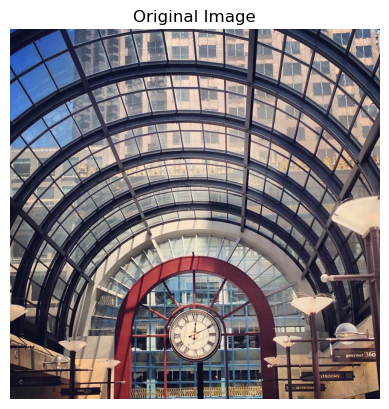

In [1]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import cv24_lab1_part2_utils as utils

# Define global parameters
SIGMA = 2
RO = 2.5
K = 0.05
THETA_CORN = 0.005
THETA_BLOB = 0.1
S = 1.5
N = 4

# Load image
image1_og = cv2.imread('urban_edges.jpg')
image1_rbg = cv2.cvtColor(image1_og, cv2.COLOR_BGR2RGB)

# Convert the image from BGR to GRAY
image1= cv2.cvtColor(image1_og, cv2.COLOR_BGR2GRAY)

# Show image
plt.imshow(image1_rbg)
plt.title('Original Image')
plt.axis('off')

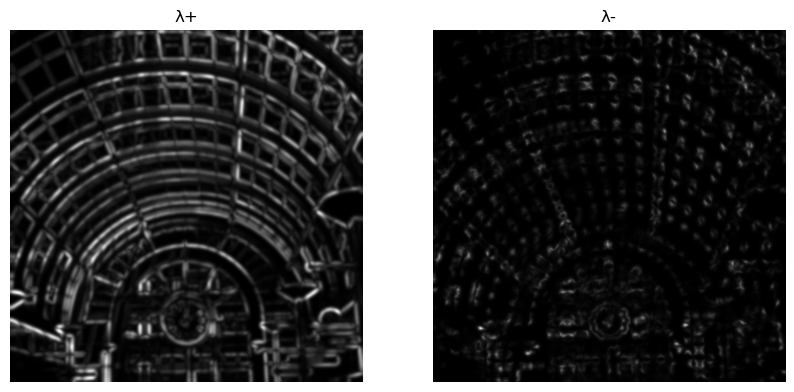

In [2]:
# Create structure tensor
I_sigma = cv2.GaussianBlur(image1, (0,0), SIGMA)
I_sy, I_sx = np.gradient(I_sigma)
J1 = cv2.GaussianBlur(I_sx*I_sx, (0,0), RO)
J2 = cv2.GaussianBlur(I_sx*I_sy, (0,0), RO)
J3 = cv2.GaussianBlur(I_sy*I_sy, (0,0), RO)

# Calculate eigenvalues
lamda_plus = (J1 + J3 + np.sqrt(np.square(J1-J3) + 4*np.square(J2)))/2
lamda_minus = (J1 + J3 - np.sqrt(np.square(J1-J3) + 4*np.square(J2)))/2

# Show image
plt.figure(figsize=(10,10))

plt.subplot(1,2,1)
plt.imshow(lamda_plus, cmap='gray')
plt.title("λ+")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(lamda_minus, cmap='gray')
plt.title("λ-")
plt.axis('off')

plt.show()

# Some cleanup
del I_sigma, I_sy, I_sx, J1, J2, J3

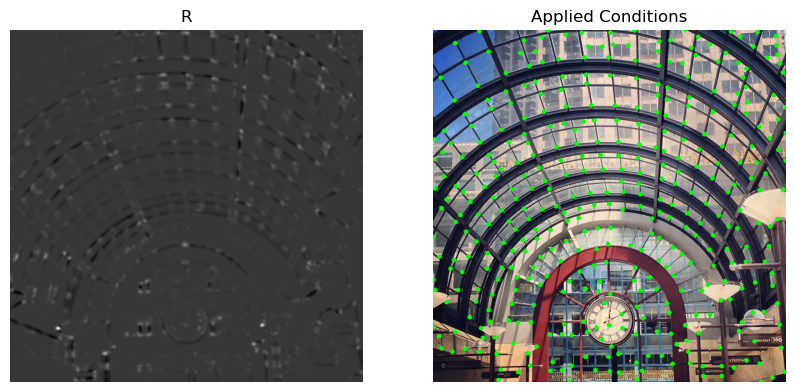

In [3]:
# Corenerness criterion
R = lamda_plus*lamda_minus - K*np.square(lamda_plus + lamda_minus)

# Condition 1
ns = np.ceil(3*SIGMA)*2+1
B_sq = utils.disk_strel(ns)
Cond1 = ( R==cv2.dilate(R,B_sq) )

# Condition 2
Cond2 = (R > THETA_CORN*np.max(R))

corners = np.logical_and(Cond1, Cond2)

# Put green dots on corners
marked_image = image1_rbg.copy()
for y, x in zip(*np.where(corners)):
    cv2.circle(marked_image, (x, y), 4, (0, 255, 0), -1)

# Show image
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(R, cmap='gray')
plt.title("R")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(marked_image, cmap='gray')
plt.title("Applied Conditions")
plt.axis('off')
plt.show()

Compose previous steps into a single function

In [4]:
def CornerDetect(image, sigma=2, ro=2.5, k=0.05, theta_corn=0.005):
    # Create structure tensor
    I_sigma = cv2.GaussianBlur(image, (0,0), sigma)
    I_sy, I_sx = np.gradient(I_sigma)
    J1 = cv2.GaussianBlur(I_sx*I_sx, (0,0), ro)
    J2 = cv2.GaussianBlur(I_sx*I_sy, (0,0), ro)
    J3 = cv2.GaussianBlur(I_sy*I_sy, (0,0), ro)

    # Calculate eigenvalues
    lamda_plus = (J1 + J3 + np.sqrt(np.square(J1-J3) + 4*np.square(J2)))/2
    lamda_minus = (J1 + J3 - np.sqrt(np.square(J1-J3) + 4*np.square(J2)))/2

    # Corenerness criterion
    R = lamda_plus*lamda_minus - k*np.square(lamda_plus + lamda_minus)

    # Condition 1
    ns = np.ceil(3*sigma)*2+1
    B_sq = utils.disk_strel(ns)
    Cond1 = ( R==cv2.dilate(R,B_sq) )

    # Condition 2
    Cond2 = (R > theta_corn*np.max(R))

    corners = np.logical_and(Cond1, Cond2)
    return corners


## 2.2 Πολυκλιμακωτή Ανίχνευση Γωνιών

In [5]:
# Run CornerDetect for multiple scales
sigmas = [S**i * SIGMA for i in range(N)]
ros = [S**i * RO for i in range(N)]
image_corners = [CornerDetect(image1, sigma, ro, THETA_CORN) for sigma, ro in zip(sigmas, ros)]

<AxesSubplot:>

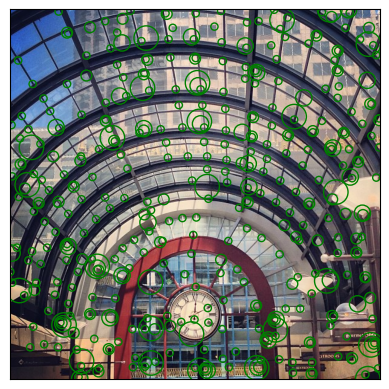

In [6]:
# Create Normalized LoG
LoG = []
for i in range(N):
    I_sigma = cv2.GaussianBlur(image1, (0,0), sigmas[i])
    I_sy, I_sx = np.gradient(I_sigma)
    Lxx = np.gradient(I_sx)[1]
    Lyy = np.gradient(I_sy)[0]
    LoG.append((sigmas[i]**2)*abs(Lxx+Lyy))

# For each scale, keep only corners that are maximum in area of 2 scales
for i in range(N):
    for y, x in zip(*np.where(image_corners[i])):
        bool1 = (LoG[i][y, x] > LoG[i-1][y, x]) if i>0 else True #if-else ensures that index stays within range
        bool2 = (LoG[i][y, x] > LoG[i+1][y, x]) if i<len(LoG)-1 else True
        image_corners[i][y, x] = bool1 and bool2

# Show result
kp_data = []
for i in range(N):
    for y, x in zip(*np.where(image_corners[i])):
        kp_data.append([x, y, sigmas[i]])

utils.interest_points_visualization(image1_rbg, kp_data)

In [2]:
def HarrisDetector(image, sigma=2, ro=2.5, k=0.05, theta_corn=0.005):
    s = 1.5
    n = 4
    # Run CornerDetect for multiple scales
    sigmas = [s**i * sigma for i in range(n)]
    ros = [s**i * ro for i in range(n)]
    image_corners = [CornerDetect(image, sigma, ro, k, theta_corn) for sigma, ro in zip(sigmas, ros)]

    # Create Normalized LoG
    LoG = []
    for i in range(n):
        I_sigma = cv2.GaussianBlur(image, (0,0), sigmas[i])
        I_sy, I_sx = np.gradient(I_sigma)
        Lxx = np.gradient(I_sx)[1]
        Lyy = np.gradient(I_sy)[0]
        LoG.append((sigmas[i]**2)*abs(Lxx+Lyy))

    # For each scale, keep only corners that are maximum in area of 2 scales
    for i in range(n):
        for y, x in zip(*np.where(image_corners[i])):
            bool1 = (LoG[i][y, x] > LoG[i-1][y, x]) if i>0 else True #if-else ensures that index stays within range
            bool2 = (LoG[i][y, x] > LoG[i+1][y, x]) if i<len(LoG)-1 else True
            image_corners[i][y, x] = bool1 and bool2

    # Show result
    kp_data = []
    for i in range(n):
        for y, x in zip(*np.where(image_corners[i])):
            kp_data.append([x, y, sigmas[i]])

    return kp_data

## 2.3 Ανίχνευση Blobs

(-0.5, 1221.5, 717.5, -0.5)

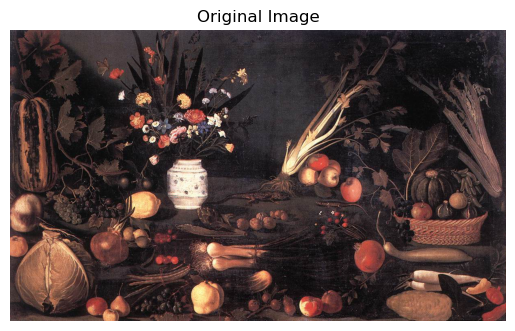

In [7]:
# Load image
image2_og = cv2.imread('Caravaggio.jpg')
image2_rbg = cv2.cvtColor(image2_og, cv2.COLOR_BGR2RGB)

# Convert the image from BGR to GRAY
image2= cv2.cvtColor(image2_og, cv2.COLOR_BGR2GRAY)

# Show image
plt.imshow(image2_rbg)
plt.title('Original Image')
plt.axis('off')

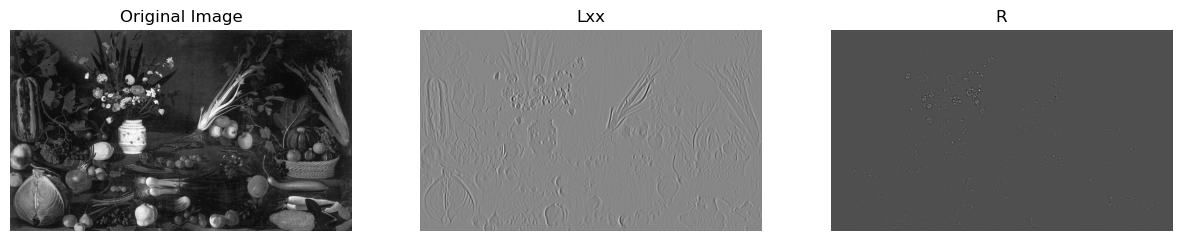

In [8]:
I_sigma = cv2.GaussianBlur(image2, (0,0), SIGMA)
I_sy, I_sx = np.gradient(I_sigma)

Lxx = np.gradient(I_sx)[1]
Lyy = np.gradient(I_sy)[0]
Lxy = np.gradient(I_sx)[0]

R = Lxx*Lyy - Lxy**2

# Condition 1
ns = np.ceil(3*SIGMA)*2+1
B_sq = utils.disk_strel(ns)
Cond1 = ( R==cv2.dilate(R,B_sq) )

# Condition 2
Cond2 = (R > THETA_BLOB*np.max(R))

blobs = np.logical_and(Cond1, Cond2)

# Put green dots on blobs
marked_image2 = image2_rbg.copy()
for y, x in zip(*np.where(blobs)):
    cv2.circle(marked_image2, (x, y), 4, (0, 255, 0), -1)

# Show results
plt.figure(figsize=(15,3))

plt.subplot(1,3,1)
plt.imshow(image2, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(Lxx, cmap='gray')
plt.title("Lxx")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(R, cmap='gray')
plt.title("R")
plt.axis('off')

#cleanup
del I_sigma, I_sy, I_sx, Lxx, Lyy, Lxy

(-0.5, 1221.5, 717.5, -0.5)

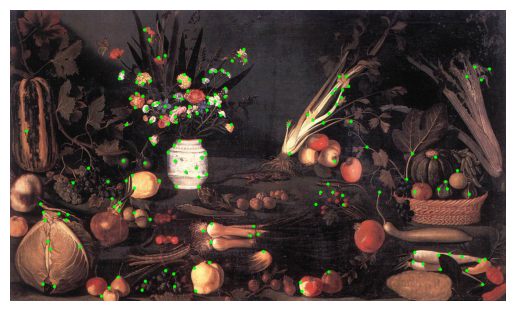

In [9]:
plt.imshow(marked_image2)
plt.axis('off')

compose all the above into a single function

In [10]:
def BlobDetect(image, sigma=2, theta_blob=0.005):
    # Hessian matrix
    I_sigma = cv2.GaussianBlur(image, (0,0), sigma)
    I_sy, I_sx = np.gradient(I_sigma)

    Lxx = np.gradient(I_sx)[1]
    Lyy = np.gradient(I_sy)[0]
    Lxy = np.gradient(I_sx)[0]

    # Blob criterion
    R = Lxx*Lyy - Lxy**2

    # Condition 1
    ns = np.ceil(3*sigma)*2+1
    B_sq = utils.disk_strel(ns)
    Cond1 = ( R==cv2.dilate(R,B_sq) )

    # Condition 2
    Cond2 = (R > theta_blob*np.max(R))

    blobs = np.logical_and(Cond1, Cond2)
    return blobs


## 2.4 Πολυκλιμακωτή Ανίχνευση Blobs

<AxesSubplot:>

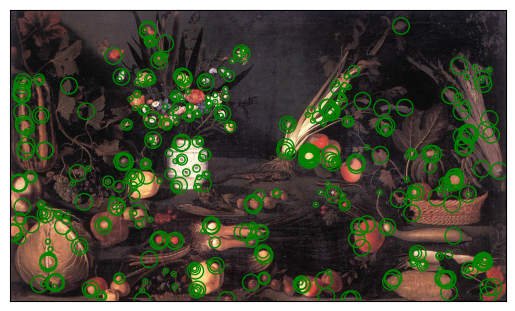

In [11]:
# Run BlobDetect for multiple scales
sigmas = [S**i * SIGMA for i in range(N)]
ros = [S**i * RO for i in range(N)]
image_blobs = [BlobDetect(image2, sigma, THETA_BLOB) for sigma, ro in zip(sigmas, ros)]

# Create Normalized LoG
LoG = []
for i in range(N):
    I_sigma = cv2.GaussianBlur(image2, (0,0), sigmas[i])
    I_sy, I_sx = np.gradient(I_sigma)
    Lxx = np.gradient(I_sx)[1]
    Lyy = np.gradient(I_sy)[0]
    LoG.append((sigmas[i]**2)*abs(Lxx+Lyy))

# For each scale, keep only corners that are maximum in area of 2 scales
for i in range(N):
    for y, x in zip(*np.where(image_blobs[i])):
        bool1 = (LoG[i][y, x] > LoG[i-1][y, x]) if i>0 else True #if-else ensures that index stays within range
        bool2 = (LoG[i][y, x] > LoG[i+1][y, x]) if i<len(LoG)-1 else True
        image_blobs[i][y, x] = bool1 and bool2

# Show result
kp_data = []
for i in range(N):
    for y, x in zip(*np.where(image_blobs[i])):
        kp_data.append([x, y, sigmas[i]])

utils.interest_points_visualization(image2_rbg, kp_data)

In [ ]:
def HessianDetector(image, sigma=2, ro=2.5, k=0.05, theta_blob=0.005, n=4):
    s = 1.5
    
    # Run BlobDetect for multiple scales
    sigmas = [s**i * sigma for i in range(n)]
    ros = [s**i * ro for i in range(n)]
    image_blobs = [BlobDetect(image, sigma, theta_blob) for sigma, ro in zip(sigmas, ros)]

    # Create Normalized LoG
    LoG = []
    for i in range(n):
        I_sigma = cv2.GaussianBlur(image, (0,0), sigmas[i])
        I_sy, I_sx = np.gradient(I_sigma)
        Lxx = np.gradient(I_sx)[1]
        Lyy = np.gradient(I_sy)[0]
        LoG.append((sigmas[i]**2)*abs(Lxx+Lyy))

    # For each scale, keep only corners that are maximum in area of 2 scales
    for i in range(n):
        for y, x in zip(*np.where(image_blobs[i])):
            bool1 = (LoG[i][y, x] > LoG[i-1][y, x]) if i>0 else True #if-else ensures that index stays within range
            bool2 = (LoG[i][y, x] > LoG[i+1][y, x]) if i<len(LoG)-1 else True
            image_blobs[i][y, x] = bool1 and bool2

    # Show result
    kp_data = []
    for i in range(n):
        for y, x in zip(*np.where(image_blobs[i])):
            kp_data.append([x, y, sigmas[i]])

    return np.array(kp_data)

## 2.5 Επιτάχυνση με την χρήση Box Filters και Ολοκληρωτικών Εικόνων

(-0.5, 1221.5, 717.5, -0.5)

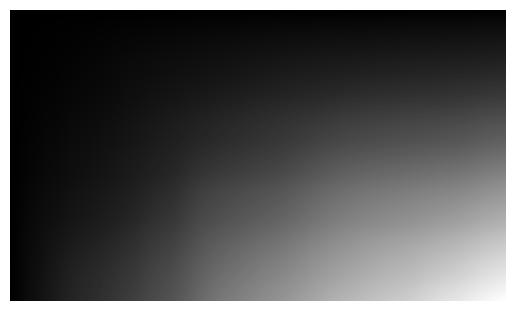

In [12]:
# Define parameters
SIGMA_BOX_FILTERS = 2

# Calculate Integral image
image2_integral = np.cumsum(np.cumsum(image2, axis=0), axis=1)
image2_integral = image2_integral.astype(np.float64)

plt.imshow(image2_integral, cmap='gray')
plt.axis('off')

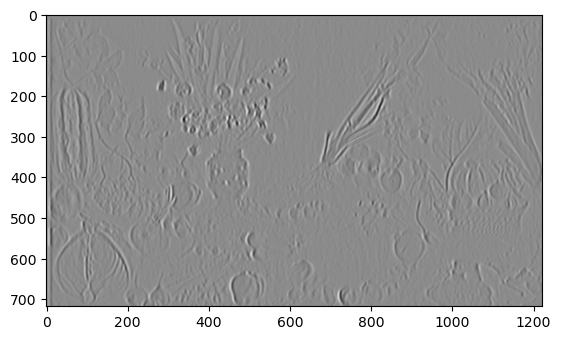

In [19]:
# Integral image sum function
def int_sum(height, width, integral_image, y, x):
    return integral_image[y, x] + integral_image[y+height, x+width] - integral_image[y+height, x] - integral_image[y, x+width]

# Apply box filters
n = 2*np.ceil(3*SIGMA_BOX_FILTERS)+1

dxx_height = int(4*np.floor(n/6)+1)
dxx_width = int(2*np.floor(n/6)+1)
dyy_height = int(2*np.floor(n/6)+1)
dyy_width = int(4*np.floor(n/6)+1)
dxy_width = int(2*np.floor(n/6)+1)
dxy_height = int(2*np.floor(n/6)+1)

image2_integral_pad = np.pad(image2_integral, ((dxx_height*2,0),(dyy_width*2,0)))
image_height, image_width = np.shape(image2)

# Dxx
Dxx = np.zeros(np.shape(image2))
for i in range(image_height):
    for j in range(image_width):
        Dxx[i,j] = int_sum(dxx_height, dxx_width, image2_integral_pad, i, j) \
                 - 2*int_sum(dxx_height, dxx_width, image2_integral_pad, i, j+dxx_width) \
                 + int_sum(dxx_height, dxx_width, image2_integral_pad, i, j+dxx_width*2)
        
# Dyy
Dyy = np.zeros(np.shape(image2))
for i in range(image_height):
    for j in range(image_width):
        Dyy[i,j] = int_sum(dyy_height, dyy_width, image2_integral_pad, i, j) \
                 - 2*int_sum(dyy_height, dyy_width, image2_integral_pad, i+dyy_height, j) \
                 + int_sum(dyy_height, dyy_width, image2_integral_pad, i+dyy_height*2, j)
                 
# Dxy
Dxy = np.zeros(np.shape(image2))
for i in range(image_height):
    for j in range(image_width):
        Dxy[i,j] = int_sum(dxy_height, dxy_width, image2_integral_pad, i, j) \
                 - int_sum(dxy_height, dxy_width, image2_integral_pad, i+dxy_height, j) \
                 - int_sum(dxy_height, dxy_width, image2_integral_pad, i, j+dxy_width) \
                 + int_sum(dxy_height, dxy_width, image2_integral_pad, i+dxy_height, j+dxy_width)

plt.imshow(Dxx, cmap='gray')

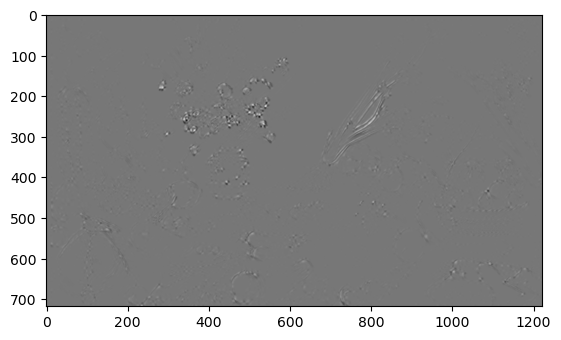

In [16]:
# Blob criteria
R = Dxx*Dyy - np.square(0.9*Dxy)

plt.imshow(R, cmap='gray')

In [17]:
def FastBlobDetect(image, sigma=2, theta_blob=0.005):
    # Calculate Integral image
    integral_image = np.cumsum(np.cumsum(image, axis=0), axis=1)
    integral_image = integral_image.astype(np.float64)
    
    # Apply box filters
    n = 2*np.ceil(3*sigma)+1

    dxx_height = int(4*np.floor(n/6)+1)
    dxx_width = int(2*np.floor(n/6)+1)
    dyy_height = int(2*np.floor(n/6)+1)
    dyy_width = int(4*np.floor(n/6)+1)
    dxy_width = int(2*np.floor(n/6)+1)
    dxy_height = int(2*np.floor(n/6)+1)

    integral_pad = np.pad(integral_image, ((dxx_height*2,0),(dyy_width*2,0)))
    image_height, image_width = np.shape(image2)

    # Dxx
    Dxx = np.zeros(np.shape(image2))
    for i in range(image_height):
        for j in range(image_width):
            Dxx[i,j] = int_sum(dxx_height, dxx_width, integral_pad, i, j) \
                    - 2*int_sum(dxx_height, dxx_width, integral_pad, i, j+dxx_width) \
                    + int_sum(dxx_height, dxx_width, integral_pad, i, j+dxx_width*2)
            
    # Dyy
    Dyy = np.zeros(np.shape(image2))
    for i in range(image_height):
        for j in range(image_width):
            Dyy[i,j] = int_sum(dyy_height, dyy_width, integral_pad, i, j) \
                    - 2*int_sum(dyy_height, dyy_width, integral_pad, i+dyy_height, j) \
                    + int_sum(dyy_height, dyy_width, integral_pad, i+dyy_height*2, j)
                    
    # Dxy
    Dxy = np.zeros(np.shape(image2))
    for i in range(image_height):
        for j in range(image_width):
            Dxy[i,j] = int_sum(dxy_height, dxy_width, integral_pad, i, j) \
                    - int_sum(dxy_height, dxy_width, integral_pad, i+dxy_height, j) \
                    - int_sum(dxy_height, dxy_width, integral_pad, i, j+dxy_width) \
                    + int_sum(dxy_height, dxy_width, integral_pad, i+dxy_height, j+dxy_width)

    # Blob criterion
    R = Dxx*Dyy - np.square(0.9*Dxy)

    # Condition 1
    ns = np.ceil(3*sigma)*2+1
    B_sq = utils.disk_strel(ns)
    Cond1 = (R==cv2.dilate(R,B_sq))

    # Condition 2
    Cond2 = (R > theta_blob*np.max(R))

    blobs = np.logical_and(Cond1, Cond2)
    return blobs


<AxesSubplot:>

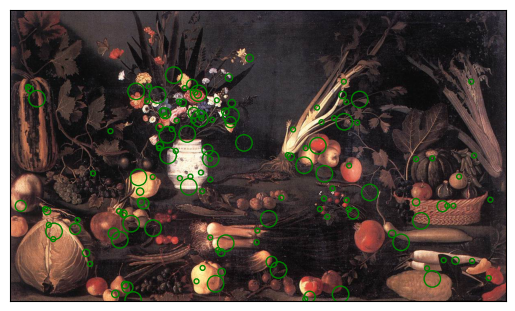

In [18]:
# Run FastBlobDetect for multiple scales
sigmas = [S**i * SIGMA for i in range(N)]
ros = [S**i * RO for i in range(N)]
image_blobs = [FastBlobDetect(image2, sigma, THETA_BLOB) for sigma, ro in zip(sigmas, ros)]

# Create Normalized LoG
LoG = []
for i in range(N):
    I_sigma = cv2.GaussianBlur(image2, (0,0), sigmas[i])
    I_sy, I_sx = np.gradient(I_sigma)
    Lxx = np.gradient(I_sx)[1]
    Lyy = np.gradient(I_sy)[0]
    LoG.append((sigmas[i]**2)*abs(Lxx+Lyy))

# For each scale, keep only corners that are maximum in area of 2 scales
for i in range(N):
    for y, x in zip(*np.where(image_blobs[i])):
        bool1 = (LoG[i][y, x] > LoG[i-1][y, x]) if i>0 else True #if-else ensures that index stays within range
        bool2 = (LoG[i][y, x] > LoG[i+1][y, x]) if i<len(LoG)-1 else True
        image_blobs[i][y, x] = bool1 and bool2

# Show result
kp_data = []
for i in range(N):
    for y, x in zip(*np.where(image_blobs[i])):
        kp_data.append([x, y, sigmas[i]])

utils.interest_points_visualization(image2_rbg, kp_data)

In [ ]:
def SURFDetector(image, sigma=2, ro=2.5, k=0.05, theta_blob=0.005, n=4):    
    s = 1.5
    
    # Run FastBlobDetect for multiple scales
    sigmas = [s**i * sigma for i in range(n)]
    ros = [s**i * ro for i in range(n)]
    image_blobs = [FastBlobDetect(image, sigma, theta_blob) for sigma, ro in zip(sigmas, ros)]

    # Create Normalized LoG
    LoG = []
    for i in range(n):
        I_sigma = cv2.GaussianBlur(image, (0,0), sigmas[i])
        I_sy, I_sx = np.gradient(I_sigma)
        Lxx = np.gradient(I_sx)[1]
        Lyy = np.gradient(I_sy)[0]
        LoG.append((sigmas[i]**2)*abs(Lxx+Lyy))

    # For each scale, keep only corners that are maximum in area of 2 scales
    for i in range(n):
        for y, x in zip(*np.where(image_blobs[i])):
            bool1 = (LoG[i][y, x] > LoG[i-1][y, x]) if i>0 else True #if-else ensures that index stays within range
            bool2 = (LoG[i][y, x] > LoG[i+1][y, x]) if i<len(LoG)-1 else True
            image_blobs[i][y, x] = bool1 and bool2

    # Show result
    kp_data = []
    for i in range(n):
        for y, x in zip(*np.where(image_blobs[i])):
            kp_data.append([x, y, sigmas[i]])

    return np.array(kp_data)